#  Final project: Sports Analytics using Deep Learning Models

**Nombres de integrantes**

**Diego Marcelo Gonzalez Lujan #588359**

**J. Esteban Bustamante Apodaca #598557**

**Mauricio Alejandro González Campos #555003**

**Inteligencia artificial 2**

**Profesor: Dr Andrés Hernández Gutiérrez**

**Mayo 7 del 2026**

**Damos nuestra palabra que realizamos esta actividad con integridad académica**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics
!pip install -U ultralytics "ray[tune]"

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 10.8 MB/s eta 0:00:00


# **Model selection**

# **Selected Architecture/Model:**

Se ha seleccionado el modelo YOLOv11, perteneciente a la familia YOLO. Se eligió esta versión específica por ser una evolución reciente que mantiene la estructura modular de "backbone", "neck" y "head", utilizando un diseño "anchor-free" para predecir coordenadas y clases simultáneamente.

# **Selected Architecture/Model:**

 * **Pretrained Weight or Trained From Scratch:**

El modelo utilizará pesos pre-entrenados obtenidos del conjunto de datos MS-COCO. Se empleará la técnica de aprendizaje por transferencia para realizar un ajuste fino, aprovechando la memoria visual previa del modelo para adaptar la detección específicamente a los jugadores y al balón de fútbol.


# **Brief Justification:**


* **Eficiencia en tiempo real:** Es el estándar para la detección de objetos en tiempo real, ofreciendo un equilibrio óptimo entre velocidad de inferencia y precisión, lo cual es crucial para procesar video de futbol.


* **Bajo costo computacional:** Requiere menos memoria y potencia de cálculo que los modelos Faster R-CNN o Transformers, lo que facilita su implementación en plataformas como Google Colab.


* **Detección de objetos pequeños:** Aunque el balón representa un reto por su tamaño, las versiones recientes de YOLO han mitigado este problema mediante mecanismos de atención y predicciones multiescala.





# Data preparation

Para la preparación de datos, nosotros implementamos un script utilizando OpenCV que automatiza la extracción de fotogramas cada 0.5 segundos, incorporando una validación de directorios para evitar procesamientos redundantes. Aunque los requerimientos de la actividad no exigían un dataset extenso, se optó por extraer un volumen inicial de 257 imágenes para garantizar la disponibilidad de información. De este conjunto, se seleccionó una muestra de 121 imágenes que fueron etiquetadas manualmente y sometidas a la división de datos para las fases de entrenamiento, validación y prueba. Las 136 imágenes se mantuvieron en reserva como respaldo, previendo su uso en caso de que se requiera una expansión del dataset para afinar la precisión del modelo.

In [ ]:
import cv2
import os

base_path = r'C:\Users\USER\Documents\Inteligencia artificial 2'
video_name = '2023_05_05_15_02_22-players-and-ball-detection.mp4'

output_dir = os.path.join(base_path, 'dataset_proyecto_final', 'raw_frames')
video_path = os.path.join(base_path, video_name)

os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: No se pudo abrir el video en la ruta: {video_path}")
    print("Verifica que el nombre del archivo sea exacto.")
else:
    # Obtener información básica del video para el reporte
    total_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    print(f"Video cargado exitosamente.")
    print(f"FPS del video: {fps}")
    print(f"Total de frames estimados: {total_frames_video}")
    print("-" * 30)
    print(f"Iniciando extracción de TODOS los frames en: {output_dir}")

    saved_count = 0

    while cap.isOpened():
        ret, frame = cap.read()

        # Si ya no hay más frames, salir del ciclo
        if not ret:
            break

        # Guardar CADA frame sin excepciones
        filename = os.path.join(output_dir, f'frame_{saved_count:05d}.jpg')
        cv2.imwrite(filename, frame)

        saved_count += 1

        # Imprimir progreso cada 100 frames para saber que el script sigue vivo
        if saved_count % 100 == 0:
            print(f"Frames procesados: {saved_count} / {total_frames_video}")

    cap.release()
    print("-" * 30)
    print(f"¡Procesamiento completado con éxito!")
    print(f"Se guardaron un total de {saved_count} imágenes.")
    print(f"Ruta final: {output_dir}")

Video cargado exitosamente.
FPS del video: 30.008101511198422
Total de frames estimados: 3846
------------------------------
Iniciando extracción de TODOS los frames en: C:\Users\USER\Documents\Inteligencia artificial 2\dataset_proyecto_final\raw_frames
Frames procesados: 100 / 3846
Frames procesados: 200 / 3846
Frames procesados: 300 / 3846
Frames procesados: 400 / 3846
Frames procesados: 500 / 3846
Frames procesados: 600 / 3846
Frames procesados: 700 / 3846
Frames procesados: 800 / 3846
Frames procesados: 900 / 3846
Frames procesados: 1000 / 3846
Frames procesados: 1100 / 3846
Frames procesados: 1200 / 3846
Frames procesados: 1300 / 3846
Frames procesados: 1400 / 3846
Frames procesados: 1500 / 3846
Frames procesados: 1600 / 3846
Frames procesados: 1700 / 3846
Frames procesados: 1800 / 3846
Frames procesados: 1900 / 3846
Frames procesados: 2000 / 3846
Frames procesados: 2100 / 3846
Frames procesados: 2200 / 3846
Frames procesados: 2300 / 3846
Frames procesados: 2400 / 3846
Frames proc

# Data labelling and splitting

Para la fase de anotación de datos, se utilizó una herramienta de código abierto en un sitio web llamado MakeSense.ai. A través de esta interfaz, se llevó a cabo el etiquetado manual de las 600 imágenes seleccionadas para el conjunto de trabajo. El proceso consistió en trazar cajas delimitadoras ajustadas de forma precisa a los contornos físicos de los objetos de interés. Este procedimiento es importante para el entrenamiento para el modelo YOLO, ya que genera los archivos de texto con las coordenadas especiales exactas que la red neuronal utiliza para poder aprender a identificar y clasificar visualmente entre las dos clases lo cuales son "player" y "ball".

In [ ]:
from google.colab import drive
import os
import shutil
from pathlib import Path
import yaml
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

drive_path = Path("/content/drive/MyDrive/PRIM26/IA2")
orig_dataset = drive_path / "Dataset_all_frames"

images_dir = orig_dataset / "Frames"
labels_dir = orig_dataset / "Labels"

out_dataset = Path("/content/Dataset_split")
test_size = 0.15
val_size = 0.15

print("Limpiando directorios anteriores...")
if out_dataset.exists():
    shutil.rmtree(out_dataset)

# Crear estructura de carpetas YOLO
for split in ["train", "val", "test"]:
    (out_dataset / "images" / split).mkdir(parents=True, exist_ok=True)
    (out_dataset / "labels" / split).mkdir(parents=True, exist_ok=True)

# Leer y dividir datos
images = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
print(f"Total de imágenes encontradas: {len(images)}")

train_imgs, temp_imgs = train_test_split(images, test_size=(test_size + val_size), random_state=42)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=(test_size / (test_size + val_size)), random_state=42)

# Función para copiar archivos
def copy_files(file_list, split_name):
    for file in file_list:

        shutil.copy(images_dir / file, out_dataset / "images" / split_name / file)

        label_file = file.replace('.jpg', '.txt')
        if (labels_dir / label_file).exists():
            shutil.copy(labels_dir / label_file, out_dataset / "labels" / split_name / label_file)

print("Copiando archivos a carpetas Train/Val/Test...")
copy_files(train_imgs, "train")
copy_files(val_imgs, "val")
copy_files(test_imgs, "test")

# Crear el archivo data.yaml
yaml_content = {
    'train': str(out_dataset / "images" / "train"),
    'val': str(out_dataset / "images" / "val"),
    'test': str(out_dataset / "images" / "test"),
    'nc': 2,
    'names': ['player', 'ball']
}

yaml_path = out_dataset / "data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(f"¡Split completado con éxito en {out_dataset}!")
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Limpiando directorios anteriores...
Total de imágenes encontradas: 600
Copiando archivos a carpetas Train/Val/Test...
¡Split completado con éxito en /content/Dataset_split!
Train: 420 | Val: 90 | Test: 90


In [ ]:
import shutil

origen = '/content/Dataset_split'

destino = '/content/drive/MyDrive/PRIM26/IA2/Dataset_split_Descomprimido'

print("Copiando archivo por archivo a tu Drive... (Ve por un café, esto va a tardar)")
shutil.copytree(origen, destino)
print("¡Copia terminada!")

Copiando archivo por archivo a tu Drive... (Ve por un café, esto va a tardar)
¡Copia terminada!


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO


model = YOLO("yolo11s.pt")

print("Iniciando Búsqueda Optimizada para Fútbol (Optuna)...")

resultados_tune = model.tune(
    data="/content/Dataset_split/data.yaml",
    use_ray=False,
    iterations=5,
    epochs=20,
    imgsz=1280,
    batch=4,
    workers=2,


    flipud=0.0,
    degrees=0.0,
    shear=0.0,
    perspective=0.0,
    mixup=0.0,
    copy_paste=0.0,


    space={
        "lr0": (1e-5, 1e-2),
        "momentum": (0.7, 0.98),
        "scale": (0.1, 0.8),     # Simula jugadores lejos/cerca
        "hsv_v": (0.1, 0.7),     # Brillo y sombras en el pasto
        "box": (1.0, 15.0),      # Ajuste estricto de la caja
        "cls": (0.1, 3.0)        # Evitar confundir balón con jugador
    },

    project="/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final",
    name="tune_optuna_futbol_limpio"
)

Iniciando Búsqueda Optimizada para Fútbol (Optuna)...
Tuner: Initialized Tuner instance with 'tune_dir=/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/tune_optuna_futbol_limpio'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/5 with hyperparameters: {'lr0': 0.01, 'momentum': 0.937, 'scale': 0.5, 'hsv_v': 0.4, 'box': 7.5, 'cls': 0.5}
Saved /content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/tune_optuna_futbol_limpio/tune_scatter_plots.png
Saved /content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/tune_optuna_futbol_limpio/tune_fitness.png

Tuner: 1/5 iterations complete ✅ (903.94s)
Tuner: Results saved to /content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/tune_optuna_futbol_limpio
Tuner: Best fitness=0.45186 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.95897, 'metrics/recall(B)': 0.94343, 'm

# Model training

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

print("Iniciando Entrenamiento Híbrido Definitivo...")

resultados_hibridos = model.train(
    data="/content/Dataset_split/data.yaml",
    epochs=60,
    imgsz=1280,
    batch=4,
    workers=2,

    # --- OPTUNA (Estabilidad matemática) ---
    lr0=0.00103,
    momentum=0.939,

    # --- LA VISIÓN ORIGINAL DE YOLO (Valores recuperados para salvar el balón) ---
    scale=0.5,
    cls=0.5,
    hsv_v=0.4,


    project="/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final",
    name="entrenamiento_hibrido_definitivo"
)

print("¡Entrenamiento Híbrido completado! Tu nuevo modelo best.pt te espera en Drive.")

Iniciando Entrenamiento Híbrido Definitivo...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Dataset_split/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00103, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.939, mosaic=1.0, multi_scale=0.0, name=entrenamiento_hibrido_definitivo-3, nbs=64, nms=Fa

--- Curvas de Entrenamiento y Validación (60 Épocas) ---


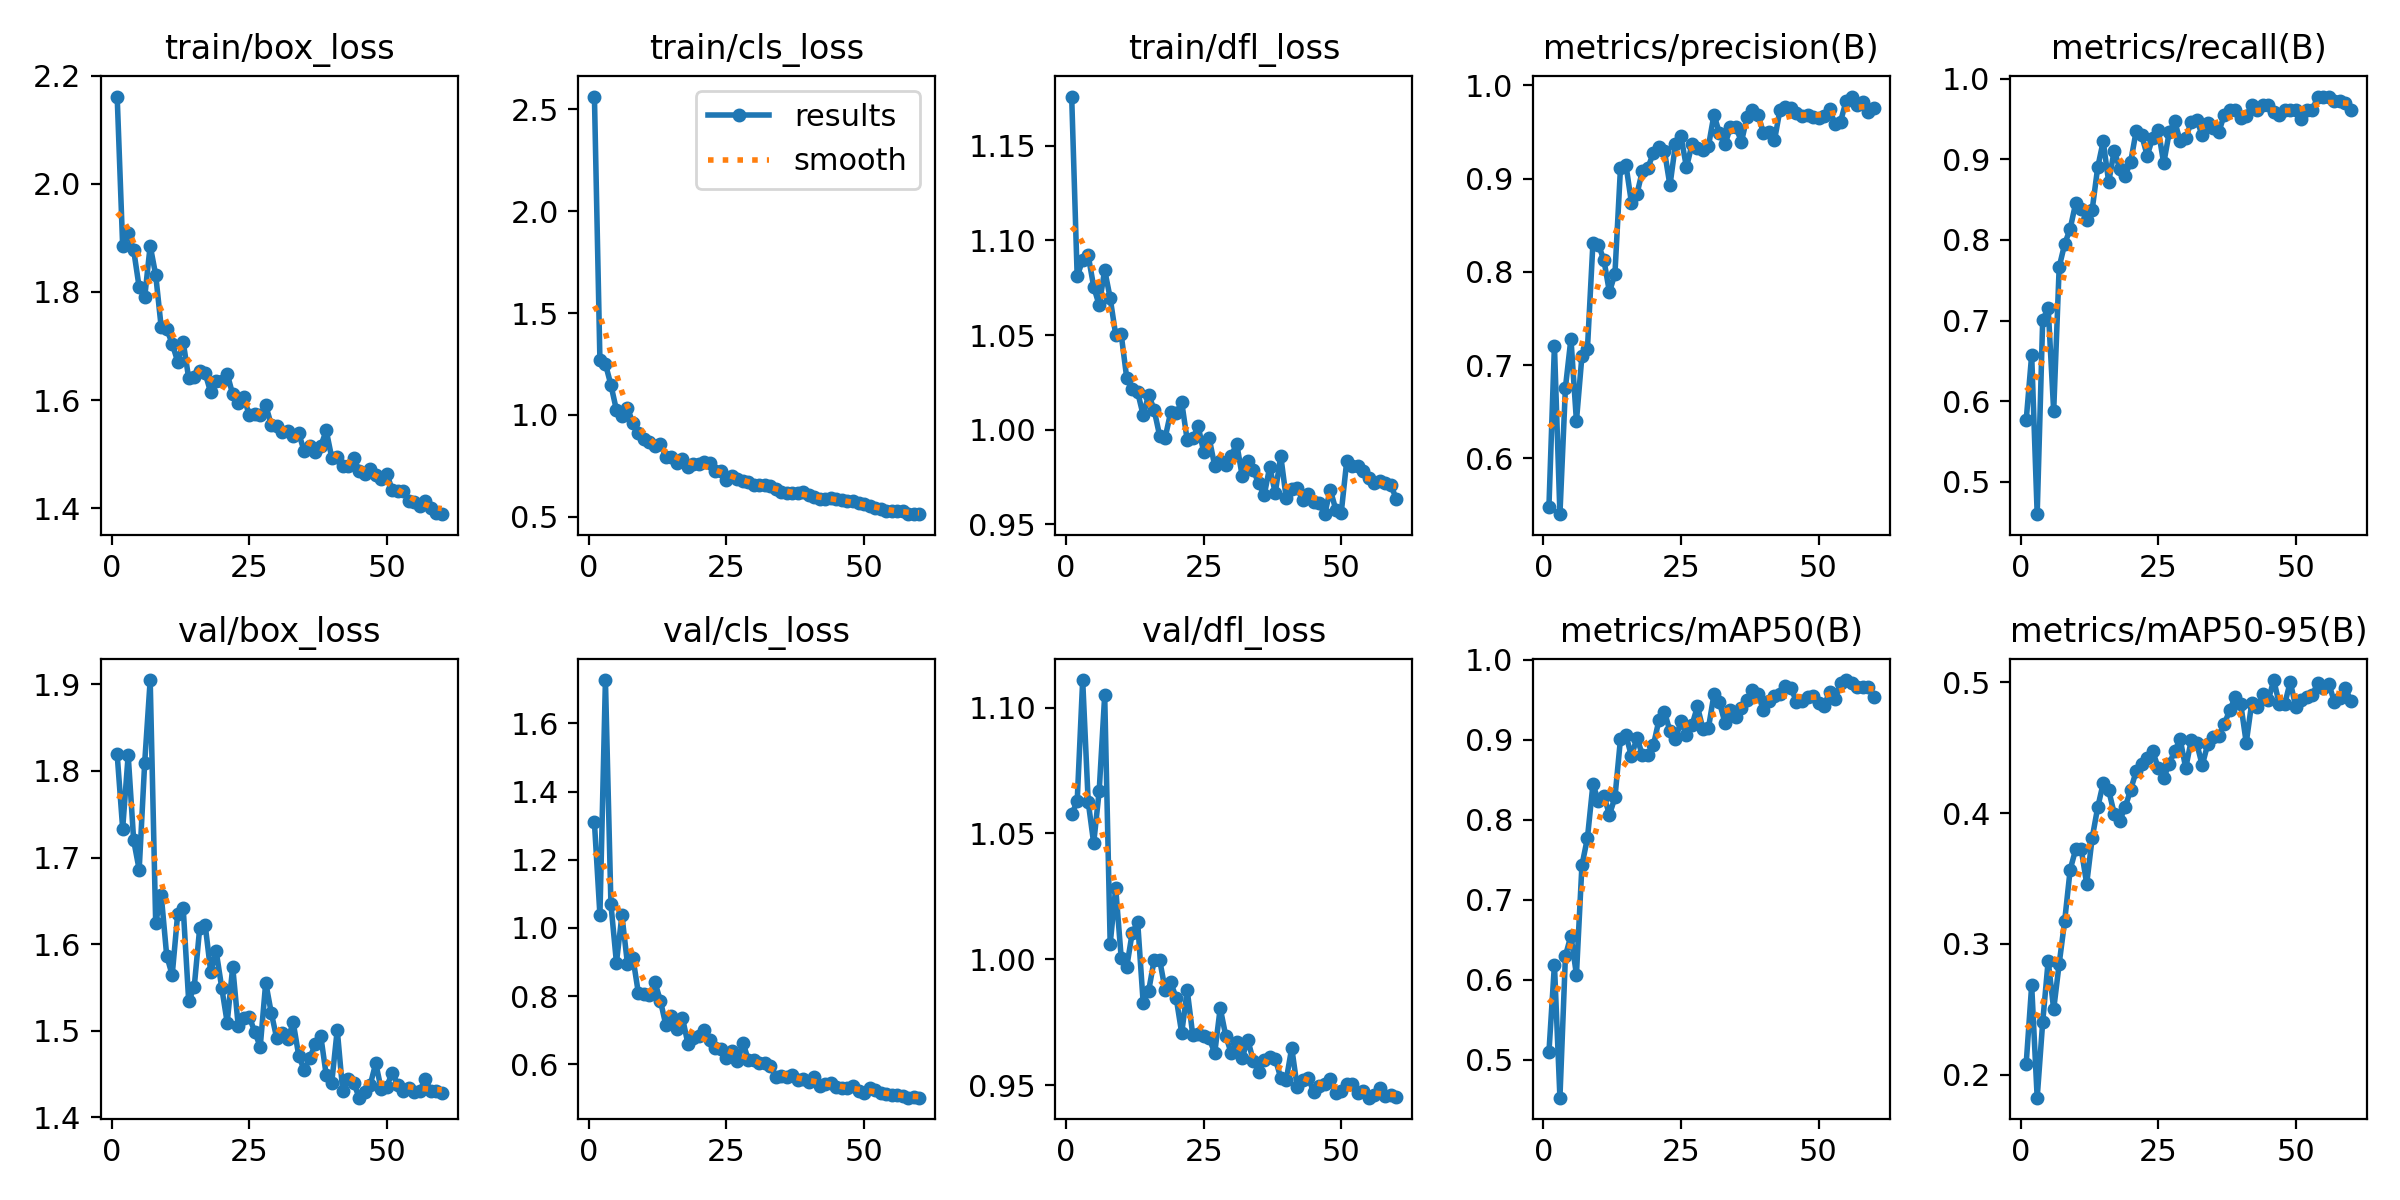


--- Matriz de Confusión ---


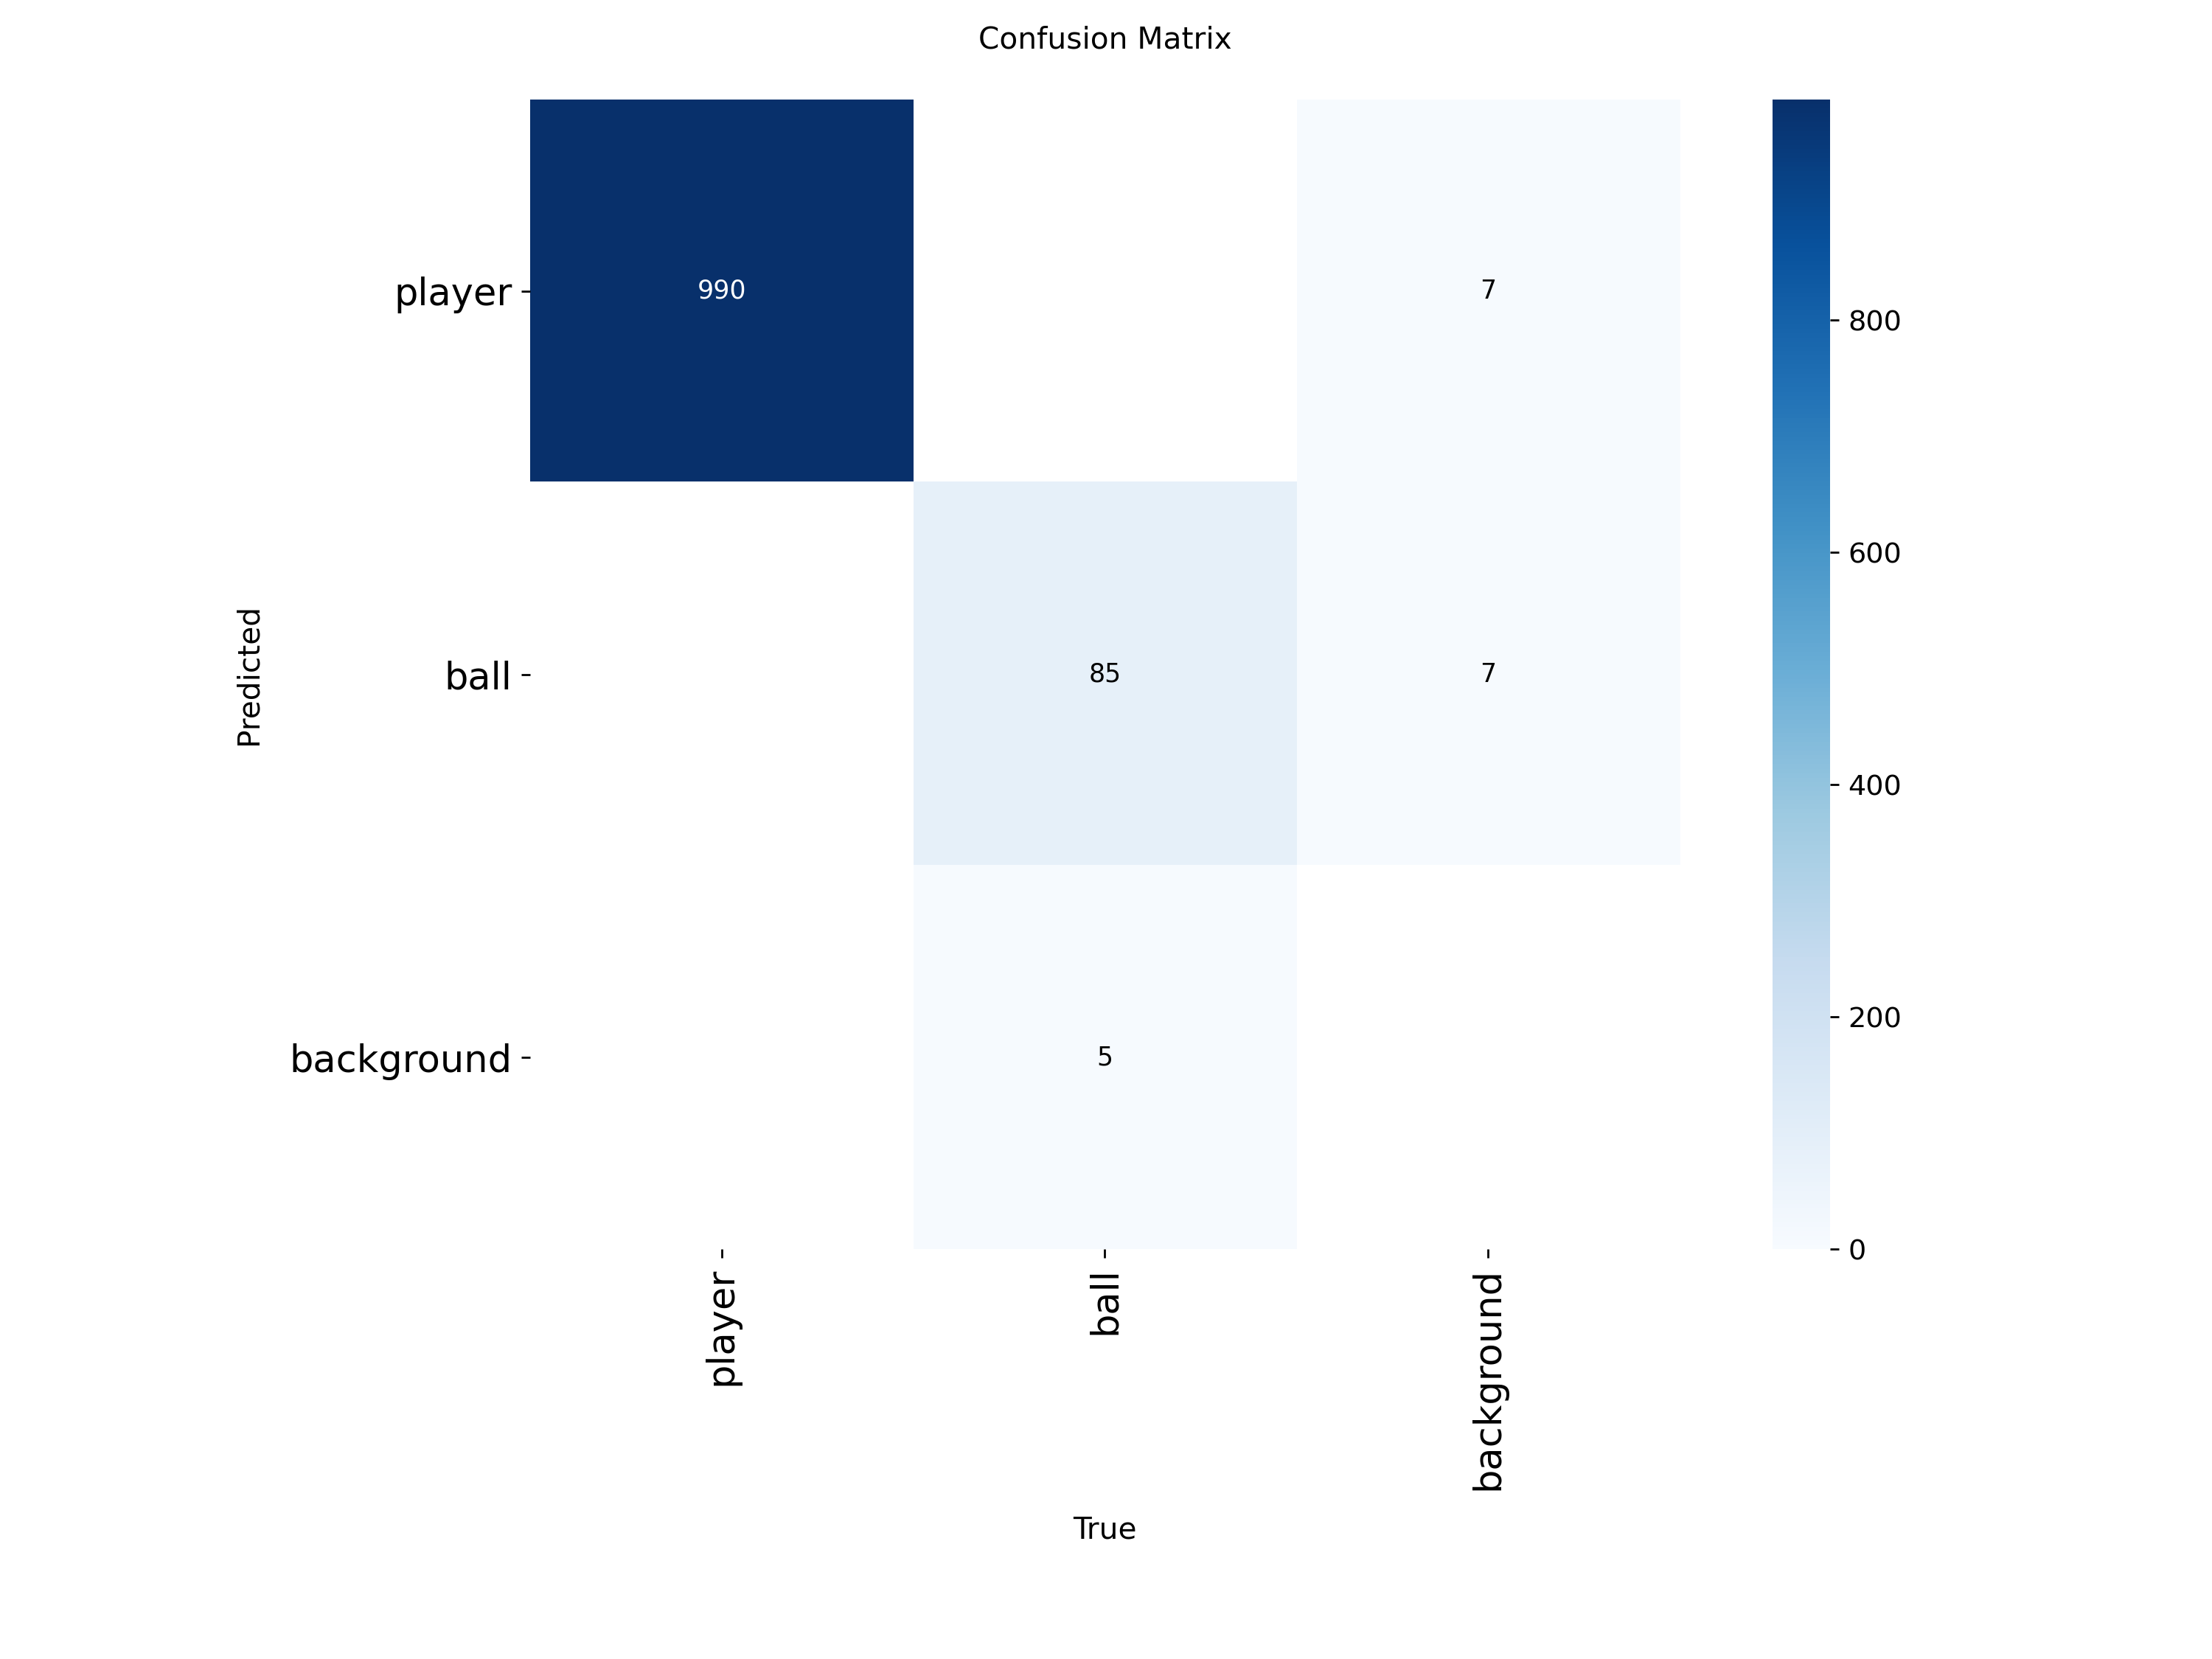


--- Ejemplos de Detección en Validación ---


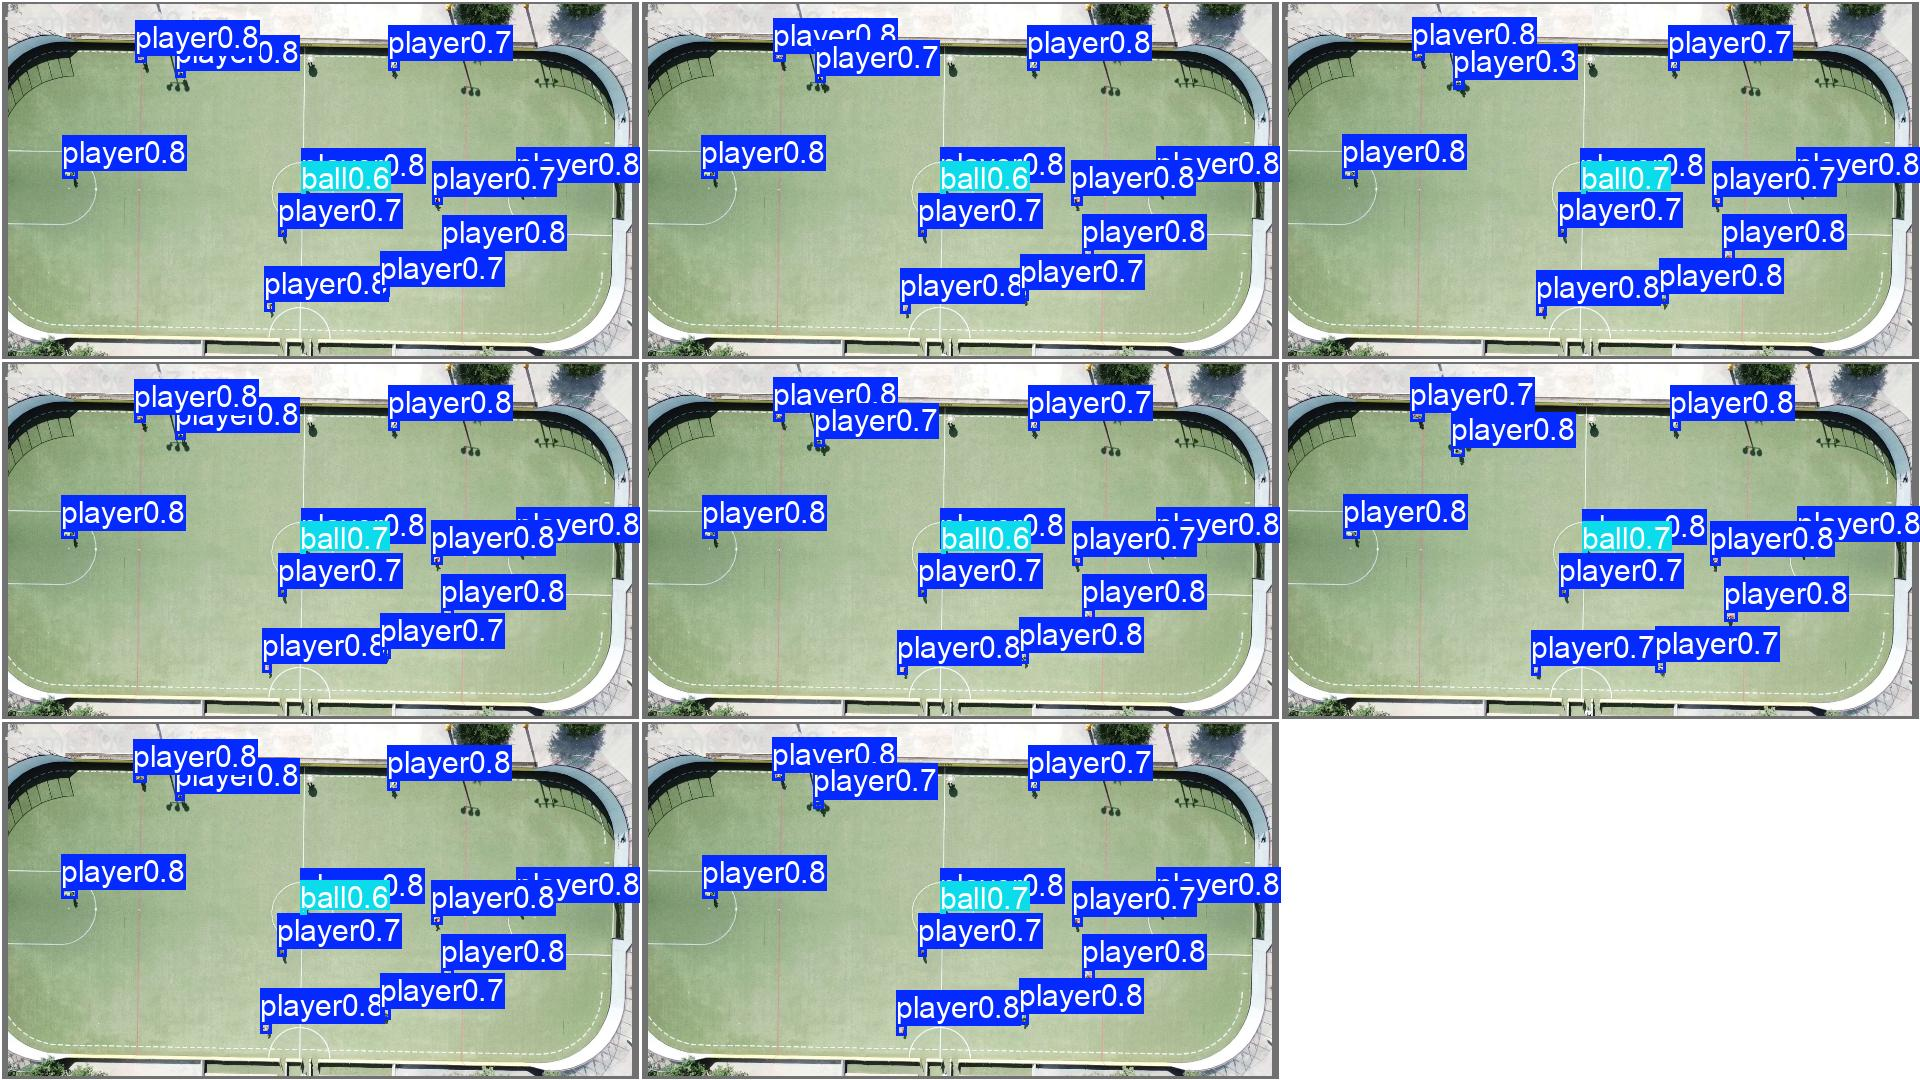

In [ ]:
from IPython.display import Image, display


ruta_resultados = '/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/entrenamiento_hibrido_definitivo-3'


print("--- Curvas de Entrenamiento y Validación (60 Épocas) ---")
display(Image(filename=f'{ruta_resultados}/results.png', width=1000))


print("\n--- Matriz de Confusión ---")
display(Image(filename=f'{ruta_resultados}/confusion_matrix.png', width=800))


print("\n--- Ejemplos de Detección en Validación ---")
display(Image(filename=f'{ruta_resultados}/val_batch0_pred.jpg', width=1000))

# Validation and testing

Iniciando evaluación con el set de Test usando el Modelo Maestro...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2482.0±679.6 MB/s, size: 310.7 KB)
val: Scanning /content/Dataset_split/labels/test.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 22.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 25.3s/it 2:32
                   all         90       1080      0.989       0.96      0.971      0.501
                player         90        990      0.995      0.997      0.994      0.591
                  ball         90         90      0.984      0.922      0.947      0.412
Speed: 32.0ms preprocess, 1626.0ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/drive/MyDrive/PRIM26/IA2/Resultados_Entr

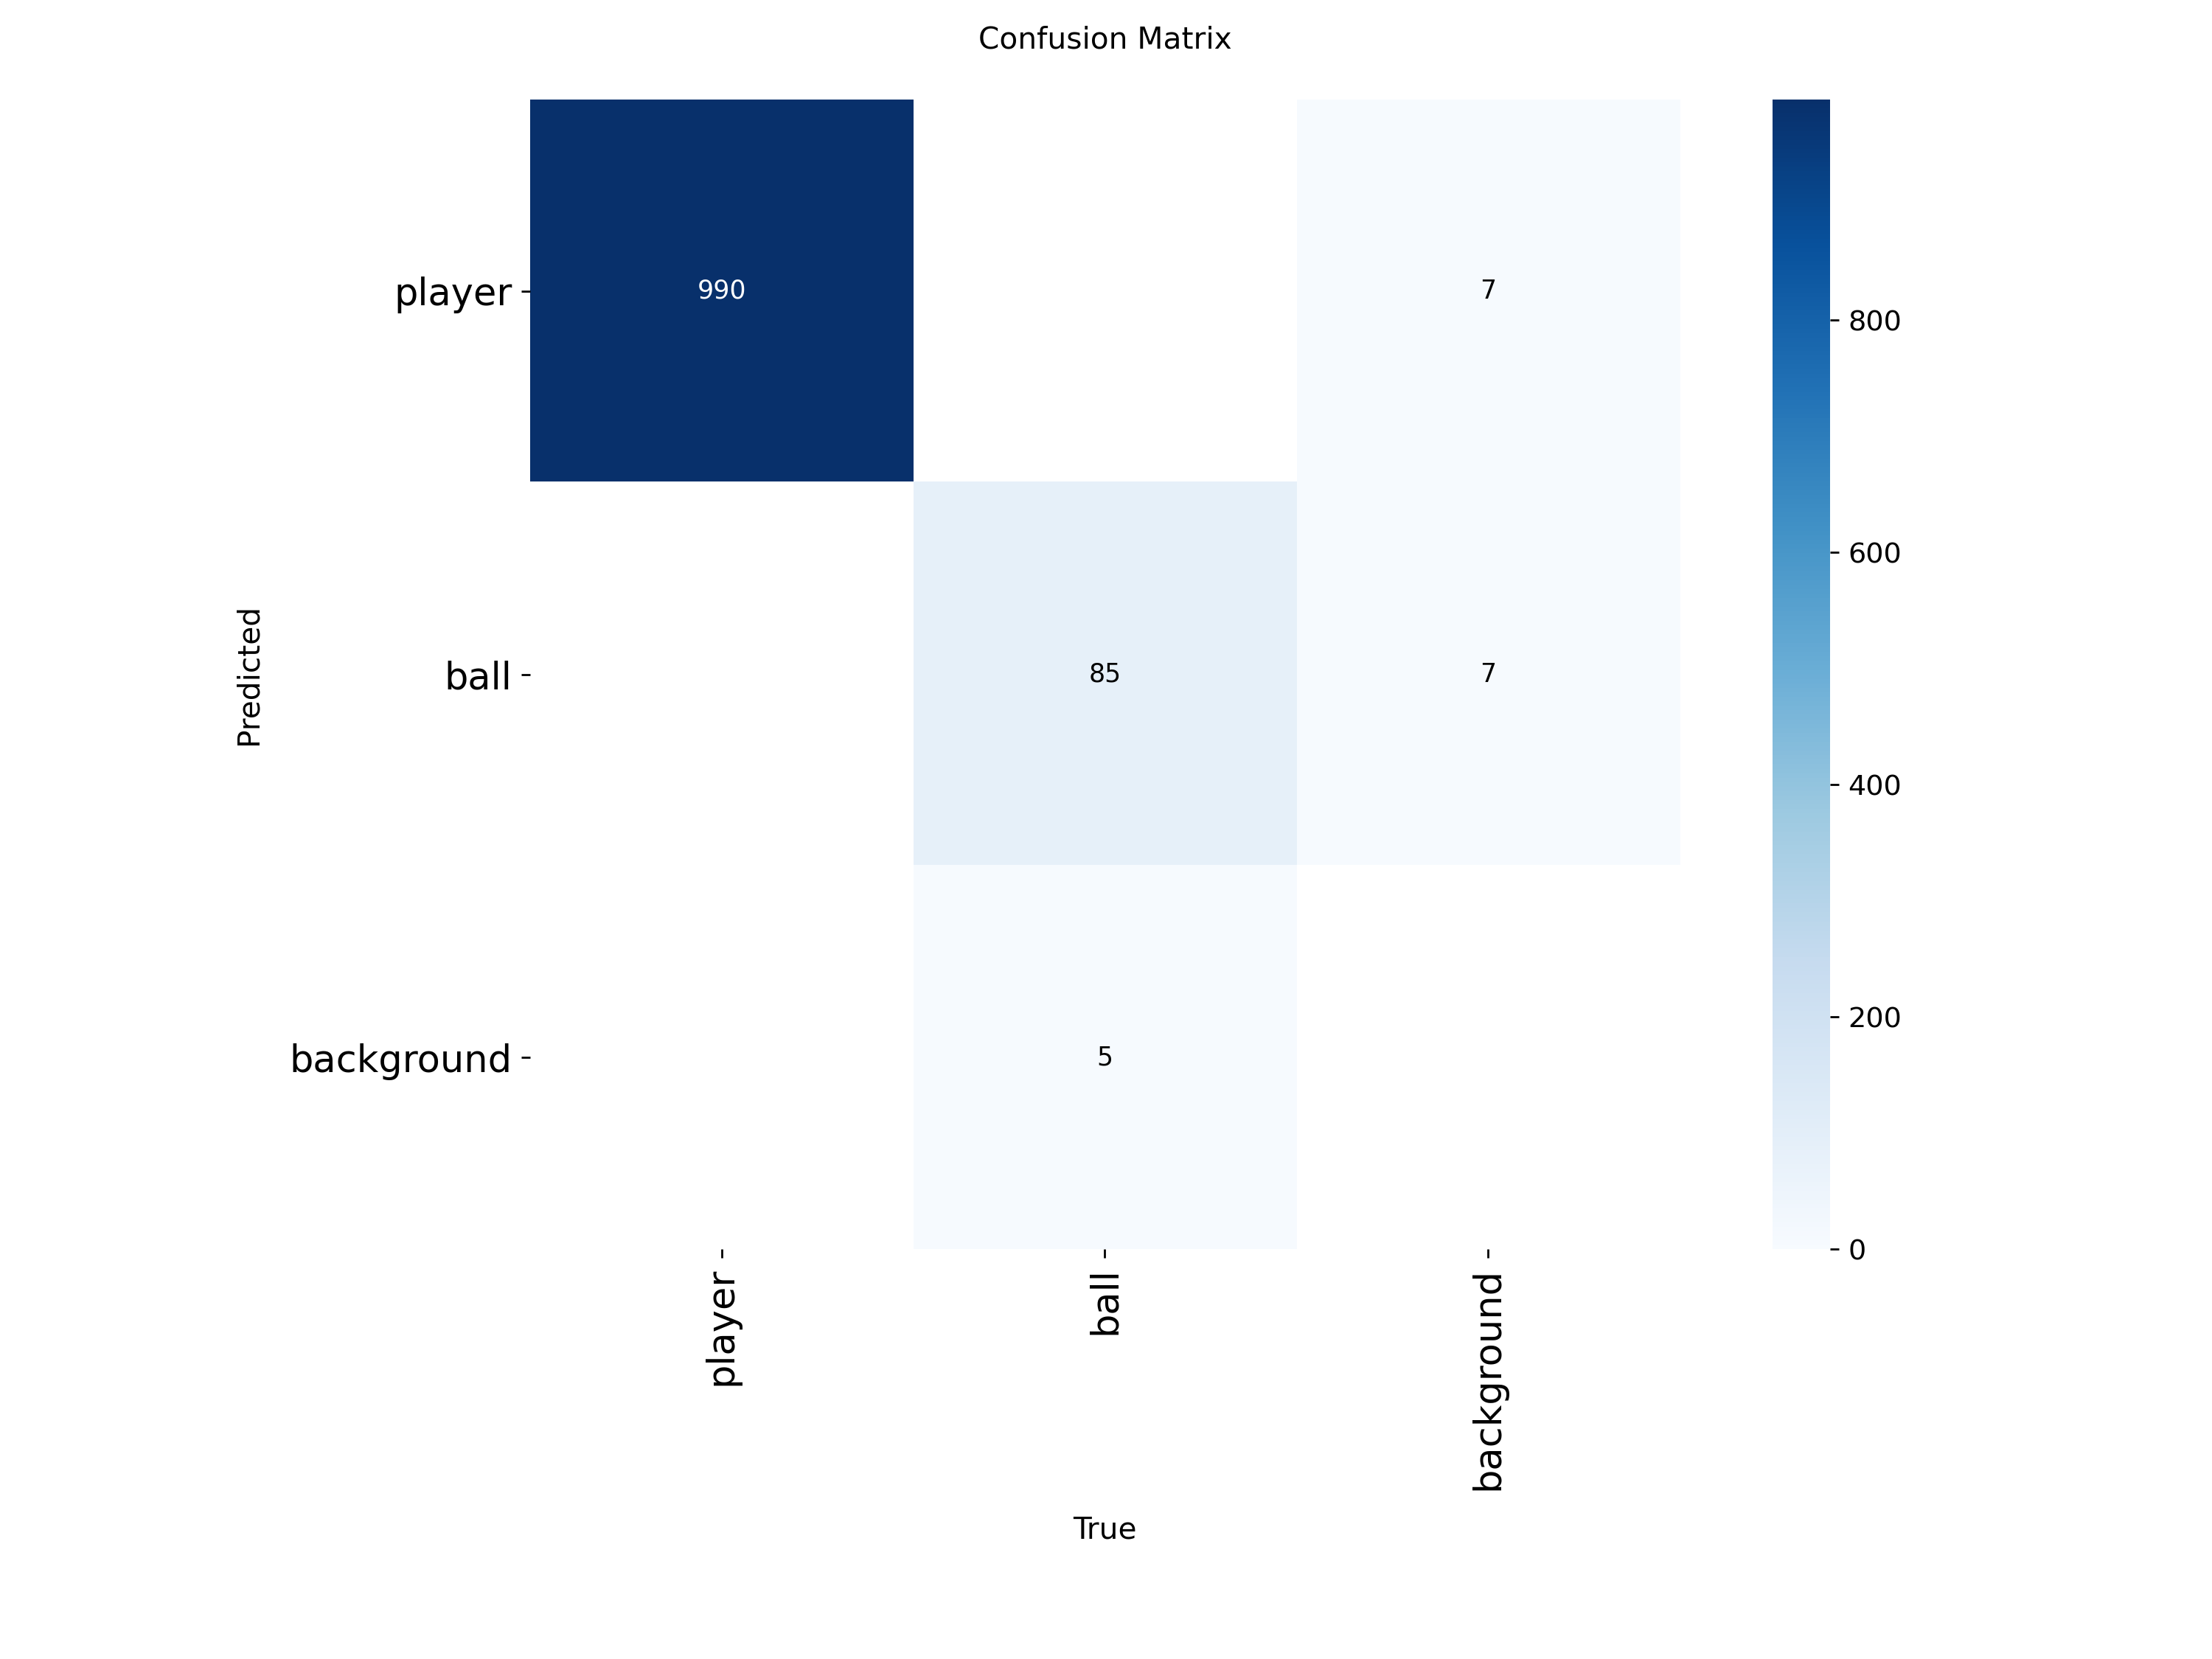

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display

ruta_pesos = "/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/entrenamiento_hibrido_definitivo-3/weights/best.pt"
model = YOLO(ruta_pesos)

print("Iniciando evaluación con el set de Test usando el Modelo Maestro...")
metrics = model.val(
    data="/content/Dataset_split/data.yaml",
    split="test",
    imgsz=1280,
    project="/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final",
    name="evaluacion_test_modelo_hibrido"
)

ruta_test = "/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/entrenamiento_hibrido_definitivo-3"
print("\n--- Matriz de Confusión (Set de Prueba - Modelo Hibrido) ---")
display(Image(filename=f"{ruta_test}/confusion_matrix.png", width=800))

# Detección y analítica visual

En esta sección se dará el resultado final donde el modelo que entrenamos pueda realizar la detección de todos los jugadores usando el video completo así como aplicar la analítica visual para determinar la posición de cada jugador en la cancha ya sea si está en uno de los dos lados del campo o en las áreas de penal, el número de jugadores en cada una de esas áreas y estos datos más el número total de jugadores se muestran en una tabla en la parte superior al centro del video.


In [ ]:
from ultralytics import YOLO

ruta_pesos = "Resultados_Entrenamiento_Proyecto_Final/entrenamiento_final_maestro/weights/best.pt"
model = YOLO(ruta_pesos)

video_entrada = "2023_05_05_15_02_22-players-and-ball-detection.mp4"

print("Procesando el video...")

resultados_v1 = model.track(
    source=video_entrada,
    imgsz=1280,
    conf=0.35,
    tracker="botsort.yaml",
    project="Resultados_Entrenamiento_Proyecto_Final",
    name="video_clases_probabilidad_final",
    save=True,
    show_conf=True,
    show_labels=True
)

print("Video procesado y guardado en tu Drive!")

Procesando el video...

WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/3846) c:\Users\esteb\Documents\Python-IA\IA2\Parcial3\PF\2023_05_05_15_02_22-players-and-ball-detection.mp4: 736x1280 11 players, 1 ball, 44.6ms
video 1/1 (frame 2/3846) c:\Users\esteb\Documents\Python-IA\IA2\Parcial3\PF\2023_05_05_15_02_22-players-and-ball-detection.mp4: 736x1280 11 players, 1 ball, 43.3ms
video 1/1 (frame 3/3846) c:\Users\esteb\Documents\Python-IA\IA2\Parcial3\PF\2023_05_05_15_02_22-players-and-ba

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

MODEL = "/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/entrenamiento_hibrido_definitivo-3/weights/best.pt"
VIDEO = "/content/drive/MyDrive/PRIM26/IA2/2023_05_05_15_02_22-players-and-ball-detection.mp4"
SALIDA = "/content/drive/MyDrive/PRIM26/IA2/Resultados_Entrenamiento_Proyecto_Final/video_zonas_jugadores_pelota_predict.mp4"

model = YOLO(MODEL)
cap = cv2.VideoCapture(VIDEO)

if not cap.isOpened():
    raise RuntimeError("No se pudo abrir el video")

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS) or 30

out = cv2.VideoWriter(
    SALIDA,
    cv2.VideoWriter_fourcc(*"mp4v"),
    FPS,
    (W, H)
)

def crear_arco(cx, cy, rx, ry, inicio, fin, n=80):
    ang = np.linspace(np.radians(inicio), np.radians(fin), n)
    pts = np.column_stack((cx + rx * np.cos(ang), cy + ry * np.sin(ang)))
    return pts.astype(np.int32)

# LINEA DIVISORA
linea_centro = [(609, 104), (599, 665)]

# AREA PENAL IZQUIERDA
arco_izq = crear_arco(125, 377, 55, 73, -90, 90)

linea_sup_izq = np.array([[0, 302], [95, 302]])
linea_inf_izq = np.array([[0, 452], [95, 452]])

penal_izq = np.vstack((
    linea_sup_izq,
    arco_izq,
    linea_inf_izq[::-1]
))

# AREA PENAL DERECHA
arco_der = crear_arco(1080, 396, 54, 73, 90, 270)

linea_sup_der = np.array([[1238, 473], [1098, 471]])
linea_inf_der = np.array([[1241, 324], [1102, 323]])

penal_der = np.vstack((
    linea_sup_der,
    arco_der,
    linea_inf_der[::-1]
))


# LIMITES DE CANCHA

linea_sup_cancha = np.array([[145, 96], [1083, 116]])
arco_sup_der = crear_arco(1083, 198, 138, 80, 270, 360)

linea_der_cancha = np.array([[1225, 245], [1220, 547]])
arco_inf_der = crear_arco(1073, 594, 140, 82, 0, 90)

linea_inf_cancha = np.array([[1073, 676], [125, 657]])
arco_inf_izq = crear_arco(125, 594, 125, 63, 90, 180)

linea_izq_cancha = np.array([[0, 594], [0, 176]])
arco_sup_izq = crear_arco(145, 176, 145, 80, 180, 270)

limites_cancha = np.vstack((
    linea_sup_cancha,
    arco_sup_der,
    linea_der_cancha,
    arco_inf_der,
    linea_inf_cancha,
    arco_inf_izq,
    linea_izq_cancha,
    arco_sup_izq
))

zonas = [
    "izquierda",
    "derecha",
    "penal_izquierdo",
    "penal_derecho",
    "fuera_cancha"
]


def lado_linea(px, py, p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    return (x2 - x1) * (py - y1) - (y2 - y1) * (px - x1)


def zona(px, py):
    if cv2.pointPolygonTest(limites_cancha, (px, py), False) < 0:
        return "fuera_cancha"

    if cv2.pointPolygonTest(penal_izq, (px, py), False) >= 0:
        return "penal_izquierdo"

    if cv2.pointPolygonTest(penal_der, (px, py), False) >= 0:
        return "penal_derecho"

    return "izquierda" if lado_linea(px, py, linea_centro[1], linea_centro[0]) < 0 else "derecha"


def dibujar_zonas(frame):
    cv2.line(frame, linea_centro[0], linea_centro[1], (0, 165, 255), 2)
    cv2.polylines(frame, [penal_izq], True, (255, 255, 0), 2)
    cv2.polylines(frame, [penal_der], True, (255, 255, 0), 2)
    cv2.polylines(frame, [limites_cancha], True, (0, 255, 0), 3)


def dibujar_tabla(frame, conteo, posicion_balon):
    x, y, w, h = W // 2 - 300, 0, 600, 100

    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 0), -1)
    cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 255, 255), 2)

    total_jugadores = sum(conteo.values())

    datos = [
        f"Lado Izquierda: {conteo['izquierda']}",
        f"Lado Derecho: {conteo['derecha']}",
        f"Penal Izquierda: {conteo['penal_izquierdo']}",
        f"Penal Derecha: {conteo['penal_derecho']}",
        f"Fuera del campo: {conteo['fuera_cancha']}",
        f"Total de jugadores: {total_jugadores}",
        f"Posicion balon: {posicion_balon}"
    ]

    for i, txt in enumerate(datos):
        px = x + 40 + (i % 2) * 300
        py = y + 30 + (i // 2) * 20

        cv2.putText(
            frame,
            txt,
            (px, py),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            2
        )


print("Procesando video con zonas, jugadores y pelota...")

while cap.isOpened():
    ok, frame = cap.read()

    if not ok:
        break

    frame_limpio = frame.copy()

    conteo = dict.fromkeys(zonas, 0)
    posicion_balon = "No detectado"

    results = model.predict(
        source=frame_limpio,
        imgsz=1280,
        conf=0.50,
        verbose=False
    )[0]

    dibujar_zonas(frame)

    if results.boxes is not None:
        for box in results.boxes:
            cls_id = int(box.cls[0])
            nombre_clase = model.names[cls_id]

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # JUGADORES
            if nombre_clase == "player":
                px = (x1 + x2) // 2
                py = (y1 + y2) // 2

                z = zona(px, py)
                conteo[z] += 1

                color = (0, 0, 255)

                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.circle(frame, (px, py), 5, (0, 255, 0), -1)

                cv2.putText(
                    frame,
                    z,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.55,
                    color,
                    2
                )

            # PELOTA
            elif nombre_clase == "ball":
                cx = (x1 + x2) // 2
                cy = (y1 + y2) // 2

                posicion_balon = zona(cx, cy)

                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

    dibujar_tabla(frame, conteo, posicion_balon)

    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

print("Video procesado y guardado en:")
print(SALIDA)

Procesando video con zonas, jugadores y pelota...
Video procesado y guardado en:
Resultados_Entrenamiento_Proyecto_Final/video_zonas_jugadores_pelota_predict.mp4
